# Finding other important rates

In [1]:
import pynucastro as pyna
import mesa_reader as mr

In [2]:
from pynucastro import mesa_utils
from pynucastro.screening import chugunov_2007

## Read in the MESA model

In [3]:
model = mr.MesaData("lab3/profile2.data")

In [4]:
nuclei = mesa_utils.get_nuclei(model)

In [5]:
mesa_zones = mesa_utils.get_all_data(model)

## Create the network using the same species as the MESA model

### Full network

By default, `network_helper` will find all the rates connecting the nuclei, some of which were likely not used in the MESA simulation.

In [6]:
net_full = pyna.network_helper(nuclei)

In [7]:
net_full.summary()

Network summary
---------------
  explicitly carried nuclei: 15
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 38

  rates explicitly connecting nuclei: 38
  hidden rates: 0

  reaclib rates: 12
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 0
  derived rates: 12
  modified rates: 0
  custom rates: 0


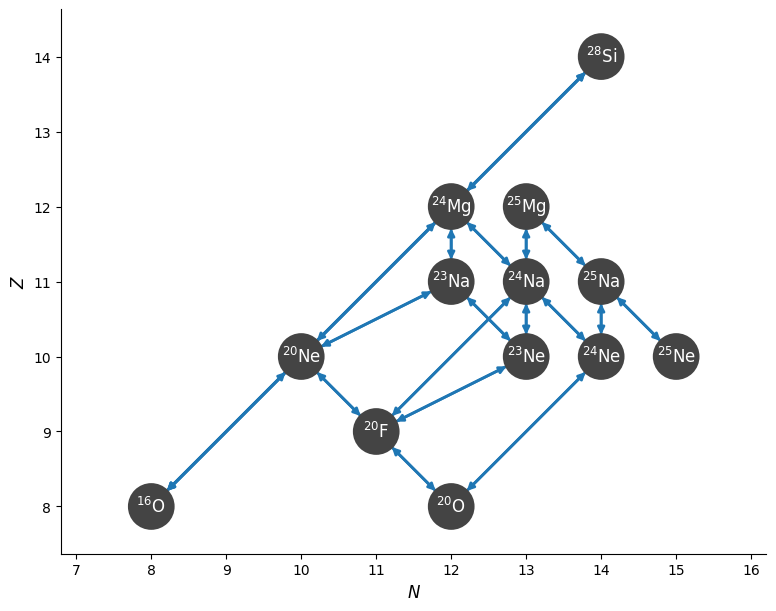

In [8]:
fig = net_full.plot()

### reduced network

separately create a network that has just the rates that we used in MESA.

In [9]:
rl = pyna.ReacLibLibrary()
tl = pyna.TabularLibrary()
all_lib = rl + tl

The MESA run uses a rate that approximates the ${}^{16}\mathrm{O} + {}^{16}\mathrm{O}$ burning through ${}^{31}\mathrm{P}$.  We'll create that rate first.

In [10]:
from pynucastro.rates.aprox_family_rates import make_CO_approx_rates
o_rates = make_CO_approx_rates(rl.get_rates(), "O")
o_lib = pyna.Library(rates=o_rates)
r1616 = o_lib.get_rate_by_name("o16(o16,a)si28")
type(r1616)

pynucastro.rates.approximate_rates.ApproximateRate

We see that `r1616` is an `ApproximateRate` that will carry multiple rates to do the approximation.

Now get all the weak rates we used in the MESA simulation

In [11]:
rate_names = ["ne20(,)f20", "f20(,)ne20",
              "f20(,)o20", "o20(,)f20",
              "mg24(,)na24", "na24(,)mg24",
              "na24(,)ne24", "ne24(,)na24",
              "na23(,)ne23", "ne23(,)na23",
              "mg25(,)na25", "na25(,)mg25",
              "na25(,)ne25", "ne25(,)na25"]


In [12]:
rates = all_lib.get_rate_by_name(rate_names)

and put it all together, eliminating any duplicates (e.g. ReacLib and Suzuki both provide the link---we prefer the Suzuki)

In [13]:
lib = pyna.Library(rates=[r1616] + rates)
lib.eliminate_duplicates()

In [14]:
net = pyna.PythonNetwork(libraries=lib)

In [15]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 14
  approximated-out nuclei: 1
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 22

  rates explicitly connecting nuclei: 15
  hidden rates: 7

  reaclib rates: 7
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 1
  derived rates: 0
  modified rates: 0
  custom rates: 0


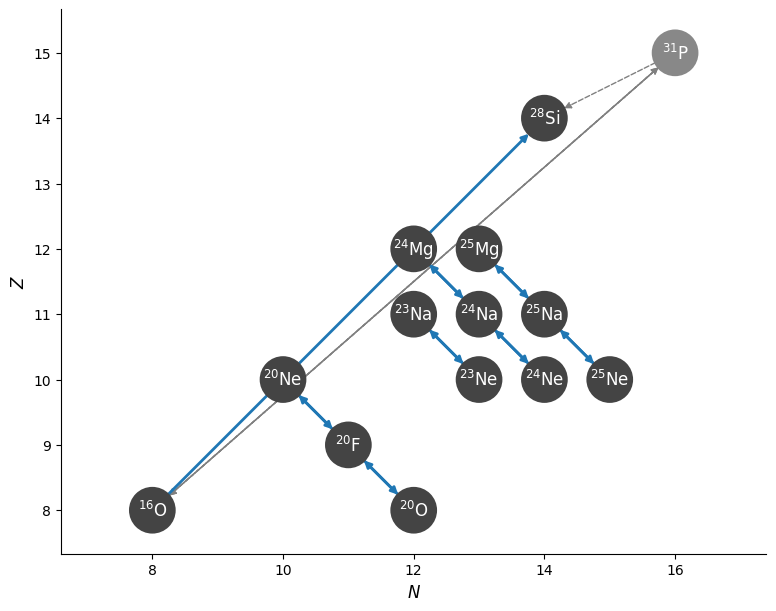

In [16]:
fig = net.plot()

## Check nuclei for other branches

In [17]:
full_library = pyna.full_library()

In [18]:
_, missing_rates = net.validate(full_library, return_dict=True)

validation: Si28 produced in O16 + O16 ⟶ Si28 + He4 never consumed.
validation: He4 produced in O16 + O16 ⟶ Si28 + He4 never consumed.


In [19]:
len(missing_rates)

82

This finds 82 other potential rates

In [20]:
lib = pyna.Library(rates=list(missing_rates.keys()))

In [22]:
lib

O16 + He4 ⟶ Ne20 + 𝛾           [Q =   4.73 MeV] (O16 + He4 --> Ne20 <reaclib_co10>)
O16 + O16 ⟶ p + P31            [Q =   7.68 MeV] (O16 + O16 --> p + P31 <reaclib_cf88>)
O16 + O16 ⟶ n + S31            [Q =   1.50 MeV] (O16 + O16 --> n + S31 <reaclib_cf88>)
O20 + He4 ⟶ n + Ne23           [Q =   3.30 MeV] (O20 + He4 --> n + Ne23 <reaclib_rpsm>)
O20 + He4 ⟶ Ne24 + 𝛾           [Q =  12.17 MeV] (O20 + He4 --> Ne24 <reaclib_rpsm>)
F20 + He4 ⟶ p + Ne23           [Q =   0.27 MeV] (F20 + He4 --> p + Ne23 <reaclib_rpsm>)
F20 + He4 ⟶ n + Na23           [Q =   3.87 MeV] (F20 + He4 --> n + Na23 <reaclib_rpsm>)
F20 + He4 ⟶ Na24 + 𝛾           [Q =  10.82 MeV] (F20 + He4 --> Na24 <reaclib_rpsm>)
Ne20 + He4 ⟶ Mg24 + 𝛾          [Q =   9.32 MeV] (Ne20 + He4 --> Mg24 <reaclib_il10>)
Ne23 + He4 ⟶ n + Mg26          [Q =   5.42 MeV] (Ne23 + He4 --> n + Mg26 <reaclib_rath>)
Ne23 + He4 ⟶ Mg27 + 𝛾          [Q =  11.86 MeV] (Ne23 + He4 --> Mg27 <reaclib_rath>)
Ne24 + He4 ⟶ n + Mg27          [Q =   2.99 MeV] (Ne

## Determine if any missing rates are important

We'll pick some zones from the MESA model to consider

In [23]:
len(mesa_zones)

786

In [24]:
import numpy as np

In [25]:
zones = np.linspace(385, 785, 11, dtype=int)
zones

array([385, 425, 465, 505, 545, 585, 625, 665, 705, 745, 785])

We only consider a rate important if it is within this threshold for the fastest capture on the same nucleus.  Since some existing rates may be very small, we also put a floor, `ydot_cutoff` on the # of reactions / sec we care about

In [26]:
thresh = 0.2
ydot_cutoff = 1.e-15

In [27]:
possibly_important = []

for izone in zones:
    rho, T, comp = mesa_zones[izone]
    for nuc in net.unique_nuclei:
        # evaluate all existing rates working with this nucleus
        r_current = {r : r.eval_full_rate(rho, T, comp, screen_func=chugunov_2007)
                     for r in net.get_rates() if nuc == max(r.reactants)}

        # evaluate all missing rates working with this nucleus
        r_missing = {r : r.eval_full_rate(rho, T, comp, screen_func=chugunov_2007)
                     for r in missing_rates if nuc == max(r.reactants)}

        # compute the fastest (abs value) current rate consuming this nucleus
        if not (r_current and r_missing):
            continue
        
        r_fastest = max(r_current, key=r_current.get)
        lambda_fastest = r_current[r_fastest]

        # now check if any missing rate is within the threshold
        possibly_important += [r for r, v in r_missing.items()
                               if v > max(ydot_cutoff, thresh * lambda_fastest)]

possibly_important = set(possibly_important)

In [28]:
possibly_important

{O16 + He4 ⟶ Ne20 + 𝛾,
 O16 + O16 ⟶ p + P31,
 O16 + O16 ⟶ n + S31,
 O20 + He4 ⟶ p + F23,
 O20 + He4 ⟶ n + Ne23,
 O20 + He4 ⟶ Ne24 + 𝛾,
 F20 + He4 ⟶ p + Ne23,
 F20 + He4 ⟶ n + Na23,
 F20 + He4 ⟶ Na24 + 𝛾,
 Ne20 + He4 ⟶ p + Na23,
 Ne20 + He4 ⟶ Mg24 + 𝛾,
 Ne23 + e⁻ ⟶ F23 + 𝜈,
 Ne23 + He4 ⟶ p + Na26,
 Ne23 + He4 ⟶ n + Mg26,
 Ne23 + He4 ⟶ Mg27 + 𝛾,
 Ne23 ⟶ n + Ne22,
 Ne24 + He4 ⟶ n + Mg27,
 Ne24 + He4 ⟶ Mg28 + 𝛾,
 Ne25 + He4 ⟶ n + Mg28,
 Ne25 ⟶ n + Ne24,
 Ne25 + He4 ⟶ Mg29 + 𝛾,
 Na23 + He4 ⟶ p + Mg26,
 Na25 + He4 ⟶ p + Mg28,
 Na25 + He4 ⟶ n + Al28,
 Na25 + He4 ⟶ Al29 + 𝛾}

which of these involve only the nuclei we are already carrying? (also allow protons)

In [29]:
okay_nuc = net.unique_nuclei + [pyna.Nucleus("p")]
filtered_rates = []
for r in possibly_important:
    okay = True
    for nuc in r.reactants + r.products:
        if nuc not in okay_nuc:
            okay = False
            break
    if okay:
        filtered_rates.append(r)

In [30]:
filtered_rates

[Ne20 + He4 ⟶ p + Na23,
 F20 + He4 ⟶ p + Ne23,
 Ne20 + He4 ⟶ Mg24 + 𝛾,
 F20 + He4 ⟶ Na24 + 𝛾,
 O16 + He4 ⟶ Ne20 + 𝛾,
 O20 + He4 ⟶ Ne24 + 𝛾]

## Network with all missing rates

In [31]:
rates = net.get_rates() + list(possibly_important)

In [32]:
big_net = pyna.PythonNetwork(rates=rates)

In [33]:
big_net.summary()

Network summary
---------------
  explicitly carried nuclei: 27
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 46

  rates explicitly connecting nuclei: 40
  hidden rates: 6

  reaclib rates: 30
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 15
  approximate rates: 1
  derived rates: 0
  modified rates: 0
  custom rates: 0


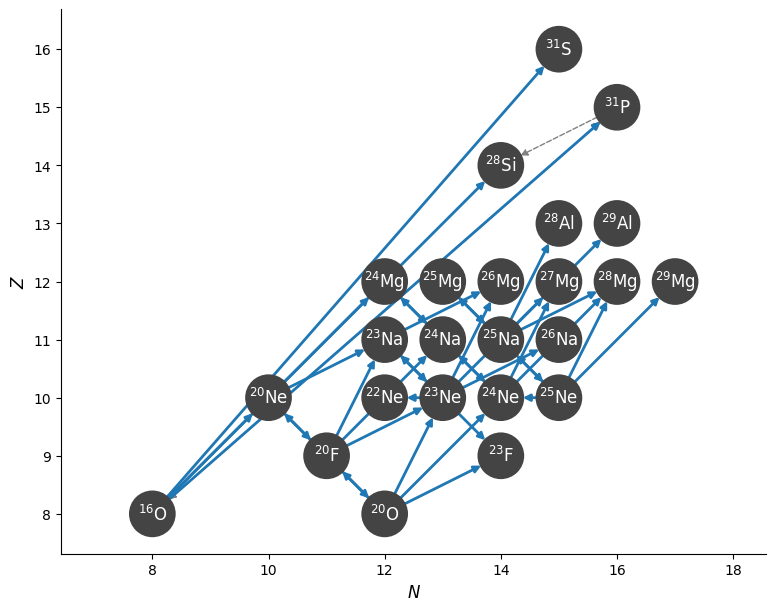

In [34]:
fig = big_net.plot()

what if we restrict it to just the rates that use the same nuclei?

In [35]:
rates = net.get_rates() + list(filtered_rates)

In [36]:
new_net = pyna.PythonNetwork(rates=rates)

In [37]:
new_net.summary()

Network summary
---------------
  explicitly carried nuclei: 15
  approximated-out nuclei: 1
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 28

  rates explicitly connecting nuclei: 21
  hidden rates: 7

  reaclib rates: 13
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 1
  derived rates: 0
  modified rates: 0
  custom rates: 0


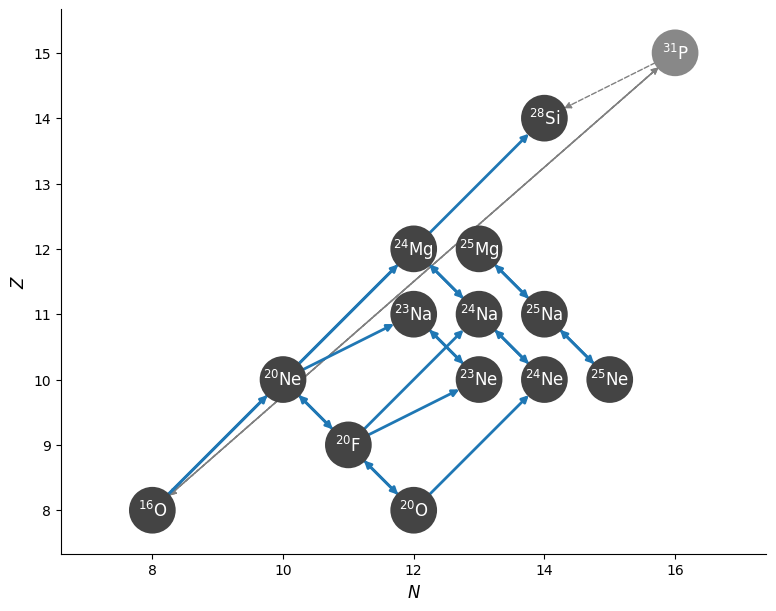

In [38]:
fig = new_net.plot()